In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Dynamics.drone_dynamics import drone_dynamics
from utility_functions import comp_quat_to_euler, decompressquat, differentiator
from scipy.spatial.transform import Rotation as R
from scipy import integrate

In [2]:
df = pd.read_csv('test_log/data_log_3.csv')
df.columns

Index(['Unnamed: 0', 'motor_timestamp', 'm1', 'm2', 'm3', 'm4',
       'bat_timestamp', 'bat_volt', 'cmd_timestamp', 'cmd_thrust',
       'mocap_output_timestamp', 'mocap_x', 'mocap_y', 'mocap_z', 'mocap_qx',
       'mocap_qy', 'mocap_qz', 'mocap_qw', 'stateZ_timestamp', 'stateZ_x',
       'stateZ_y', 'stateZ_z', 'stateZ_quat', 'stateZ_vx', 'stateZ_vy',
       'stateZ_vz', 'stateZ_rollrate', 'stateZ_pitchrate', 'stateZ_yawrate',
       'state_timestamp', 'state_roll', 'state_pitch', 'state_yaw'],
      dtype='object')

In [3]:
df.isna().sum()

Unnamed: 0                   0
motor_timestamp              1
m1                           1
m2                           1
m3                           1
m4                           1
bat_timestamp                4
bat_volt                     4
cmd_timestamp                1
cmd_thrust                   1
mocap_output_timestamp    1432
mocap_x                   1432
mocap_y                   1432
mocap_z                   1432
mocap_qx                  1432
mocap_qy                  1432
mocap_qz                  1432
mocap_qw                  1432
stateZ_timestamp             0
stateZ_x                     0
stateZ_y                     0
stateZ_z                     0
stateZ_quat                  0
stateZ_vx                    0
stateZ_vy                    0
stateZ_vz                    0
stateZ_rollrate              0
stateZ_pitchrate             0
stateZ_yawrate               0
state_timestamp           1432
state_roll                1432
state_pitch               1432
state_ya

In [4]:
roll = []
pitch = []
yaw = []
for i in range(200,df['stateZ_timestamp'].shape[0]-200):
    rpy = comp_quat_to_euler((df['stateZ_quat'][i])) # in radians
    roll.append(rpy[0])
    pitch.append(rpy[1])
    yaw.append(rpy[2])


In [5]:
## Force Computations
# f1 = 2.130295*(10**(-11))*(df['m1']**2) + 1.032633*(10**(-6))*df['m1'] + 5.484560*(10**(-4))
# f2 = 2.130295*(10**(-11))*(df['m2']**2) + 1.032633*(10**(-6))*df['m2'] + 5.484560*(10**(-4))
# f3 = 2.130295*(10**(-11))*(df['m3']**2) + 1.032633*(10**(-6))*df['m3'] + 5.484560*(10**(-4))
# f4 = 2.130295*(10**(-11))*(df['m4']**2) + 1.032633*(10**(-6))*df['m4'] + 5.484560*(10**(-4))

f1 = 0.091492681*((df['m1']/65536)**2) + 0.067673604*(df['m1']/65536)
f2 = 0.091492681*((df['m2']/65536)**2) + 0.067673604*(df['m2']/65536)
f3 = 0.091492681*((df['m3']/65536)**2) + 0.067673604*(df['m3']/65536)
f4 = 0.091492681*((df['m4']/65536)**2) + 0.067673604*(df['m4']/65536)

In [6]:
x = []
y = []
z = []

x_dot = []
y_dot = []
z_dot = []

roll_model = []
pitch_model = []
yaw_model = []

roll_dot_model = []
pitch_dot_model = []
yaw_dot_model = []
thr_tot = []
x_torques = []
y_torques = []
z_torques = []
params = {}
t=0

acc_x_data = []
acc_y_data = []
acc_z_data = []

r_dd_data = []
p_dd_data = []
y_dd_data = []

time = []
ts=[]

for i in range(200, df['stateZ_timestamp'].shape[0]-200):
    if i == 200:
        params['pos'] = 0*np.array([df['stateZ_x'][i], df['stateZ_y'][i], df['stateZ_z'][i]])/1000 # position in m
        params['vel'] = 0*np.array([df['stateZ_vx'][i], df['stateZ_vy'][i], df['stateZ_vz'][i]])/1000 # position in m
        # params['vel'] = xyz_dot
        params['quat'] = 0*decompressquat(df['stateZ_quat'][i])
        params['rpy'] = 0*comp_quat_to_euler((df['stateZ_quat'][i])) # in radians
        params['rpy_rates'] = 0*np.array([df['stateZ_rollrate'][i], df['stateZ_pitchrate'][i], df['stateZ_yawrate'][i]])/1000 # in radians/s
    # params['rpy_rates'] = rpy_rates
        params['dt'] = 1/100 #s

    else:
        params['pos'] = np.array([x_i,y_i,z_i])#xyz # position in m
        params['vel'] = np.array([x_di,y_di,z_di]) # position in m
        # params['vel'] = xyz_dot
        r = R.from_euler('xyz', np.array([r_i,p_i,ya_i]), degrees=False)
        params['quat'] = r.as_quat()
        # params['quat'] = decompressquat(df['stateZ_quat'][i])
        params['rpy'] = np.array([r_i,p_i,ya_i]) #rpy # in radians
        params['rpy_rates'] = np.array([r_di,p_di,ya_di]) # in radians/s
        # params['rpy_rates'] = rpy_rates
        
        params['dt'] = (df['stateZ_timestamp'][i]-df['stateZ_timestamp'][i-1])/1000 #s
    
    
    
    params['pos'] = np.array([df['stateZ_x'][i], df['stateZ_y'][i], df['stateZ_z'][i]])/1000 # position in m
    params['vel'] = np.array([df['stateZ_vx'][i], df['stateZ_vy'][i], df['stateZ_vz'][i]])/1000 # position in m
    # params['vel'] = xyz_dot
    params['quat'] = decompressquat(df['stateZ_quat'][i])
    params['rpy'] = comp_quat_to_euler((df['stateZ_quat'][i])) # in radians
    params['rpy_rates'] = np.array([df['stateZ_rollrate'][i], df['stateZ_pitchrate'][i], df['stateZ_yawrate'][i]])/1000 # in radians/s
    # params['rpy_rates'] = rpy_rates
    thrusts = np.array([f1[i],f2[i],f3[i],f4[i]])
    thr_tot.append(np.sum(thrusts))
    # print(thrusts)
    KF = 3.1582e-10
    KM = 7.9379e-12
    L = 0.046#0.0397
    thr_2_torque = 0.005964552
    
    #z_torques = forces*KM/KF
    z_torque = (-f1[i] + f2[i] - f3[i] + f4[i]) * thr_2_torque
    x_torque = (-f1[i] - f2[i] + f3[i] + f4[i]) * (L/np.sqrt(2))
    y_torque = (-f1[i] + f2[i] + f3[i] - f4[i]) * (L/np.sqrt(2))
    
    x_torques.append(x_torque)
    y_torques.append(y_torque)
    z_torques.append(z_torque)
    
    
    _, _, acc, _, _, rpy_ddot, _, _= drone_dynamics(params, thrusts)
    
    ts.append(df['stateZ_timestamp'][i])
    
    
    # if i < 6:
#     xyz_dot = params['vel'] + acc*params['dt']
#     xyz = params['pos'] + xyz_dot*params['dt'] + (1/2)*acc*(params['dt']**2) 

#     rpy_rates = params['rpy_rates'] + rpy_ddot*params['dt']
#     rpy = params['rpy'] + rpy_rates*params['dt'] + (1/2)*rpy_ddot*(params['dt']**2)
        
#     else:
#         # ra_dot = (ra[-1,:] + 2*ra[-2,:] - 2*ra[-4,:] - ra[-5,:])/(8*dt)
#         xyz_dot = np.array([x_dot[-4],y_dot[-4],z_dot[-4]]) + 2*np.array([x_dot[-3],y_dot[-3],z_dot[-3]])-2*np.array([x_dot[-1],y_dot[-1],z_dot[-1]]) + acc*8*params['dt']
#         xyz = np.array([x[-4],y[-4],z[-4]]) + 2*np.array([x[-3],y[-3],z[-3]])-2*np.array([x[-1],y[-1],z[-1]]) + xyz_dot*8*params['dt']
        
#         rpy_rates = np.array([roll_dot_model[-4],pitch_dot_model[-4],yaw_dot_model[-4]]) + 2*np.array([roll_dot_model[-3],pitch_dot_model[-3],yaw_dot_model[-3]])-2*np.array([roll_dot_model[-1],pitch_dot_model[-1],yaw_dot_model[-1]]) + rpy_ddot*8*params['dt']
        
#         rpy = np.array([roll_model[-4],pitch_model[-4],yaw_model[-4]]) + 2*np.array([roll_model[-3],pitch_model[-3],yaw_model[-3]])-2*np.array([roll_model[-1],pitch_model[-1],yaw_model[-1]]) + rpy_rates*8*params['dt']
        
        
    acc_x_data.append(acc[0])
    acc_y_data.append(acc[1])
    acc_z_data.append(acc[2])
    
    t += 0.01
    time.append(t)
    x_di = integrate.trapz(acc_x_data, time)
    y_di = integrate.trapz(acc_y_data, time)
    z_di = integrate.trapz(acc_z_data, time)
    
    x_dot.append(x_di)
    y_dot.append(y_di)
    z_dot.append(z_di)
    
    x_i = integrate.trapz(x_dot, time)
    y_i = integrate.trapz(y_dot, time)
    z_i = integrate.trapz(z_dot, time)
    
    x.append(x_i)
    y.append(y_i)
    z.append(z_i)
    
    r_dd_data.append(rpy_ddot[0])
    p_dd_data.append(rpy_ddot[1])
    y_dd_data.append(rpy_ddot[2])
    
    r_di = integrate.trapz(r_dd_data,time)
    p_di = integrate.trapz(p_dd_data,time)
    ya_di = integrate.trapz(y_dd_data,time)
    
    roll_dot_model.append(r_di)
    pitch_dot_model.append(p_di)
    yaw_dot_model.append(ya_di)
    
    r_i = integrate.trapz(roll_dot_model,time)
    p_i = integrate.trapz(pitch_dot_model,time)
    ya_i = integrate.trapz(yaw_dot_model,time)
    
    roll_model.append(r_i)
    pitch_model.append(p_i)
    yaw_model.append(ya_i)
    
#     x.append(xyz[0])
#     y.append(xyz[1])
#     z.append(xyz[2])
    
#     x_dot.append(xyz_dot[0])
#     y_dot.append(xyz_dot[1])
#     z_dot.append(xyz_dot[2])
    
#     roll_model.append(rpy[0])
#     pitch_model.append(rpy[1])
#     yaw_model.append(rpy[2])
    
#     roll_dot_model= 
#     pitch_dot_model.append(rpy_rates[1])
#     yaw_dot_model.append(rpy_rates[2])
    


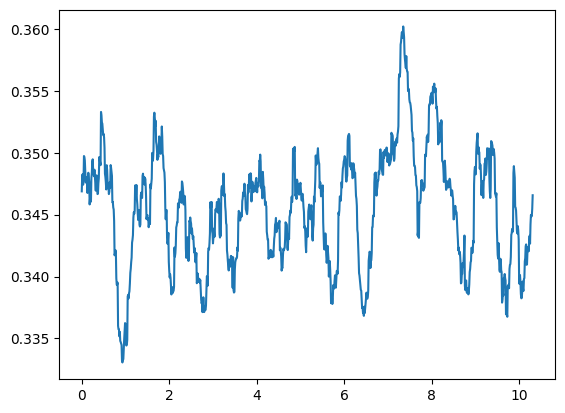

In [7]:
plt.figure
# plt.plot((df['stateZ_timestamp']-df['stateZ_timestamp'][0])/1000,thr_tot)
plt.plot((ts-ts[0])/1000,thr_tot)

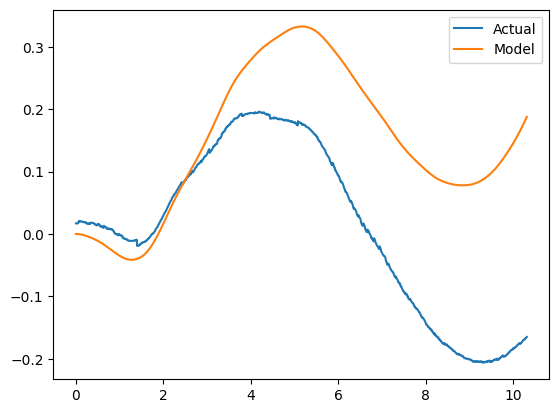

In [8]:
# x
plt.figure
plt.plot((ts-ts[0])/1000,df['stateZ_x'][200:-200]/1000, label = 'Actual')
plt.plot((ts-ts[0])/1000,x, label = 'Model')
plt.legend()

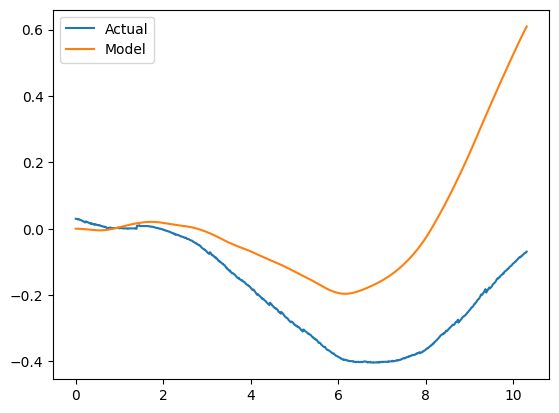

In [9]:
# y
plt.figure
plt.plot((ts-ts[0])/1000,df['stateZ_y'][200:-200]/1000, label = 'Actual')
plt.plot((ts-ts[0])/1000,y, label = 'Model')
plt.legend()

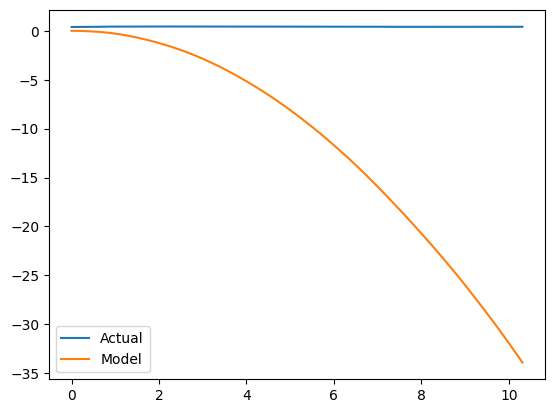

In [10]:
# z
plt.figure
plt.plot((ts-ts[0])/1000,df['stateZ_z'][200:-200]/1000, label = 'Actual')
plt.plot((ts-ts[0])/1000,z, label = 'Model')
plt.legend()

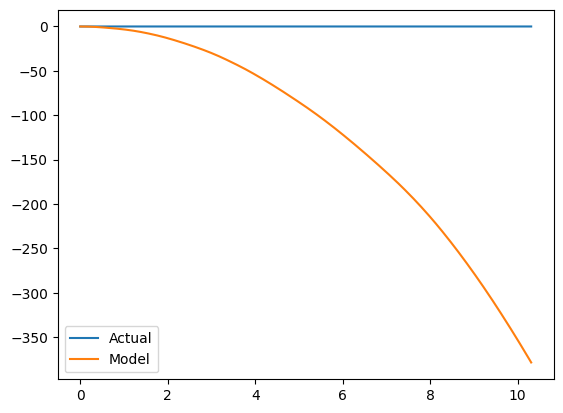

In [11]:
# Roll
plt.figure
plt.plot((ts-ts[0])/1000,roll, label = 'Actual')
plt.plot((ts-ts[0])/1000,roll_model, label = 'Model')
plt.legend()

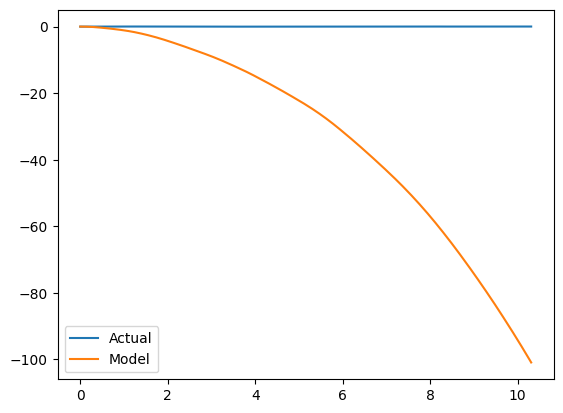

In [12]:
# Pitch
plt.figure
plt.plot((ts-ts[0])/1000,pitch, label = 'Actual')
plt.plot((ts-ts[0])/1000,pitch_model, label = 'Model')
plt.legend()

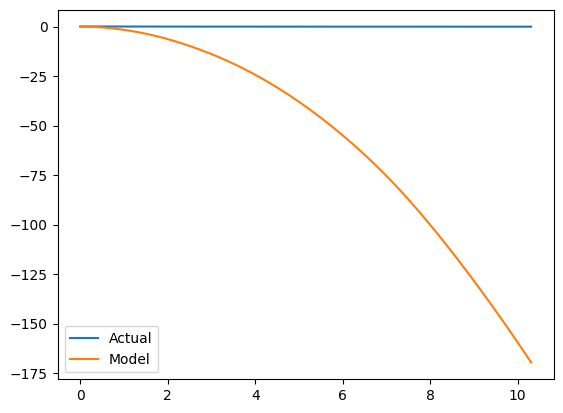

In [13]:
# Yaw
plt.figure
plt.plot((ts-ts[0])/1000,yaw, label = 'Actual')
plt.plot((ts-ts[0])/1000,yaw_model, label = 'Model')
plt.legend()

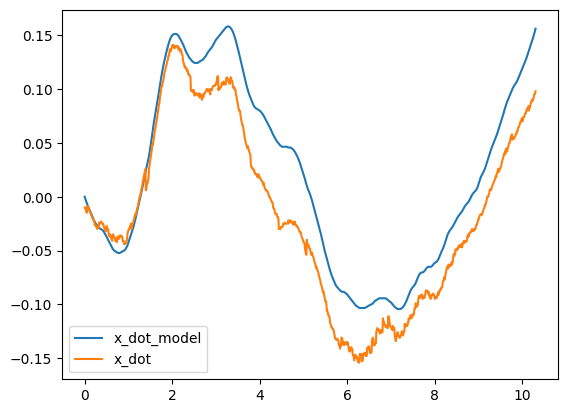

In [14]:
# X_dot
plt.figure()
plt.plot((ts-ts[0])/1000,x_dot, label = 'x_dot_model')
plt.plot((ts-ts[0])/1000,df['stateZ_vx'][200:-200]/1000, label = 'x_dot')
plt.legend()

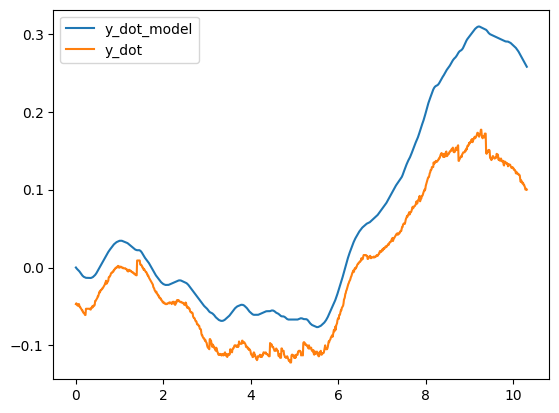

In [15]:
# Y_dot
plt.figure()
plt.plot((ts-ts[0])/1000,y_dot, label = 'y_dot_model')
plt.plot((ts-ts[0])/1000,df['stateZ_vy'][200:-200]/1000, label = 'y_dot')
plt.legend()

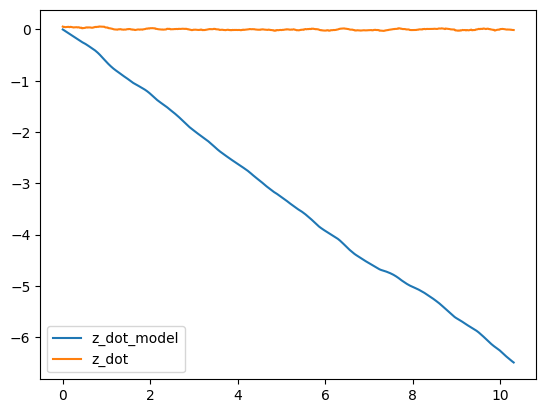

In [16]:
# Z_dot
plt.figure()
plt.plot((ts-ts[0])/1000,z_dot, label = 'z_dot_model')
plt.plot((ts-ts[0])/1000,df['stateZ_vz'][200:-200]/1000, label = 'z_dot')
plt.legend()

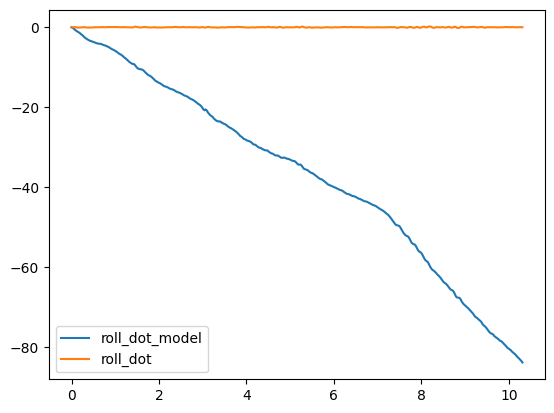

In [17]:
# Roll_dot
plt.figure()
plt.plot((ts-ts[0])/1000,roll_dot_model, label = 'roll_dot_model')
plt.plot((ts-ts[0])/1000,df['stateZ_rollrate'][200:-200]/1000, label = 'roll_dot')
plt.legend()

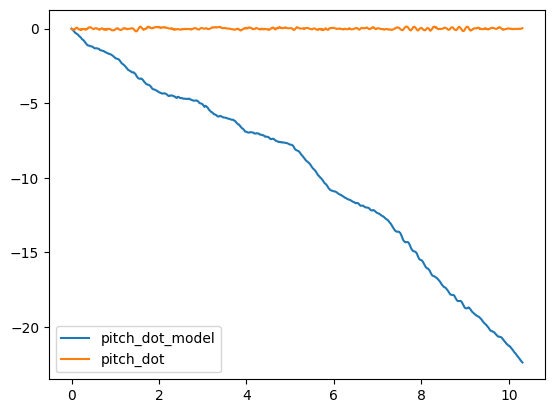

In [18]:
# Pitch_dot
plt.figure()
plt.plot((ts-ts[0])/1000,pitch_dot_model, label = 'pitch_dot_model')
plt.plot((ts-ts[0])/1000,df['stateZ_pitchrate'][200:-200]/1000, label = 'pitch_dot')
plt.legend()

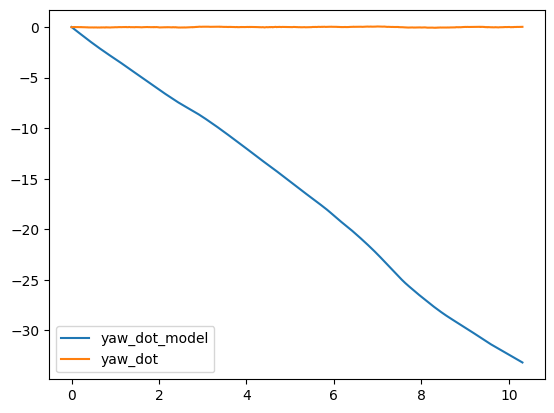

In [19]:
# Yaw_dot
plt.figure()
plt.plot((ts-ts[0])/1000,yaw_dot_model, label = 'yaw_dot_model')
plt.plot((ts-ts[0])/1000,df['stateZ_yawrate'][200:-200]/1000, label = 'yaw_dot')
plt.legend()

In [20]:
## Calculation of parameters
time_diff = df['stateZ_timestamp'].diff()/1000
tim_diff = time_diff[200:-200]

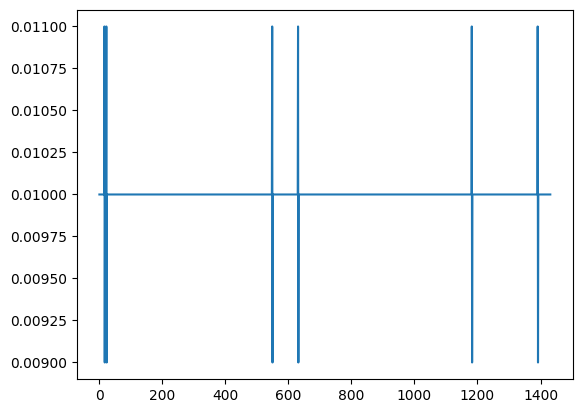

In [21]:
plt.figure()
plt.plot(time_diff)

In [22]:
## accels
# acc_x = (df['stateZ_vx'][200:-200].diff())/(1000*time_diff)
# acc_y = (df['stateZ_vy'][200:-200].diff())/(1000*time_diff)
# acc_z = (df['stateZ_vz'][200:-200].diff())/(1000*time_diff)

# # acc_r = (df['stateZ_rollrate'].diff())/(1000*time_diff)
# acc_p = (df['stateZ_pitchrate'][200:-200].diff())/(1000*time_diff)
# acc_ya = (df['stateZ_yawrate'][200:-200].diff())/(1000*time_diff)

roll = np.array(roll).reshape(-1,1)

vel_r = np.zeros_like(roll)
acc_r = np.zeros_like(roll)

for i in range(vel_r.shape[0]-1):
    vel_r[i+1,:],acc_r[i+1,:] = differentiator(roll[:i+2,:],vel_r[:i+2,:],time_diff[i+1])
    
    ## smoothening window for more accurate acceleration
    window = 2
    if i > window:
        vel_r[i+1,:] = np.mean(vel_r[i-window:i+2,:],axis = 0)
        vel_r[i+1,:] = np.mean(vel_r[i-window:i+2,:],axis = 0)
        
        acc_r[i+1,:] = np.mean(acc_r[i-window:i+2,:],axis = 0)
        acc_r[i+1,:] = np.mean(acc_r[i-window:i+2,:],axis = 0)
    else:
        vel_r[i+1,:] = np.mean(vel_r[:i+2,:],axis = 0)
        acc_r[i+1,:] = np.mean(vel_r[:i+2,:],axis = 0)
        
        
pitch = np.array(pitch).reshape(-1,1)

vel_p = np.zeros_like(pitch)
acc_p = np.zeros_like(pitch)

for i in range(vel_p.shape[0]-1):
    vel_p[i+1,:],acc_p[i+1,:] = differentiator(pitch[:i+2,:],vel_p[:i+2,:],time_diff[i+1])
    
    ## smoothening window for more accurate acceleration
    window = 2
    if i > window:
        vel_p[i+1,:] = np.mean(vel_p[i-window:i+2,:],axis = 0)
        vel_p[i+1,:] = np.mean(vel_p[i-window:i+2,:],axis = 0)
        
        acc_p[i+1,:] = np.mean(acc_p[i-window:i+2,:],axis = 0)
        acc_p[i+1,:] = np.mean(acc_p[i-window:i+2,:],axis = 0)
    else:
        vel_p[i+1,:] = np.mean(vel_p[:i+2,:],axis = 0)
        acc_p[i+1,:] = np.mean(vel_p[:i+2,:],axis = 0)
        
yaw = np.array(yaw).reshape(-1,1)

vel_ya = np.zeros_like(yaw)
acc_ya = np.zeros_like(yaw)

for i in range(vel_ya.shape[0]-1):
    vel_ya[i+1,:],acc_ya[i+1,:] = differentiator(yaw[:i+2,:],vel_ya[:i+2,:],time_diff[i+1])
    
    ## smoothening window for more accurate acceleration
    window = 2
    if i > window:
        vel_ya[i+1,:] = np.mean(vel_ya[i-window:i+2,:],axis = 0)
        vel_ya[i+1,:] = np.mean(vel_ya[i-window:i+2,:],axis = 0)
        
        acc_ya[i+1,:] = np.mean(acc_ya[i-window:i+2,:],axis = 0)
        acc_ya[i+1,:] = np.mean(acc_ya[i-window:i+2,:],axis = 0)
    else:
        vel_ya[i+1,:] = np.mean(vel_ya[:i+2,:],axis = 0)
        acc_ya[i+1,:] = np.mean(vel_ya[:i+2,:],axis = 0)
        
roll = np.array(roll).reshape(-1)
pitch = np.array(pitch).reshape(-1)
yaw = np.array(yaw).reshape(-1)

In [23]:
x = np.array(x).reshape(-1,1)

vel_x = np.zeros_like(x)
acc_x = np.zeros_like(x)

for i in range(vel_x.shape[0]-1):
    vel_x[i+1,:],acc_x[i+1,:] = differentiator(x[:i+2,:],vel_x[:i+2,:],time_diff[i+1])
    
    ## smoothening window for more accurate acceleration
    window = 2
    if i > window:
        vel_x[i+1,:] = np.mean(vel_x[i-window:i+2,:],axis = 0)
        vel_x[i+1,:] = np.mean(vel_x[i-window:i+2,:],axis = 0)
        
        acc_x[i+1,:] = np.mean(acc_x[i-window:i+2,:],axis = 0)
        acc_x[i+1,:] = np.mean(acc_x[i-window:i+2,:],axis = 0)
    else:
        vel_x[i+1,:] = np.mean(vel_x[:i+2,:],axis = 0)
        acc_x[i+1,:] = np.mean(vel_x[:i+2,:],axis = 0)
        
        
y = np.array(y).reshape(-1,1)

vel_y = np.zeros_like(y)
acc_y = np.zeros_like(y)

for i in range(vel_p.shape[0]-1):
    vel_y[i+1,:],acc_y[i+1,:] = differentiator(y[:i+2,:],vel_y[:i+2,:],time_diff[i+1])
    
    ## smoothening window for more accurate acceleration
    window = 2
    if i > window:
        vel_y[i+1,:] = np.mean(vel_y[i-window:i+2,:],axis = 0)
        vel_y[i+1,:] = np.mean(vel_y[i-window:i+2,:],axis = 0)
        
        acc_y[i+1,:] = np.mean(acc_y[i-window:i+2,:],axis = 0)
        acc_y[i+1,:] = np.mean(acc_y[i-window:i+2,:],axis = 0)
    else:
        vel_y[i+1,:] = np.mean(vel_y[:i+2,:],axis = 0)
        acc_y[i+1,:] = np.mean(vel_y[:i+2,:],axis = 0)
        
z = np.array(z).reshape(-1,1)

vel_z = np.zeros_like(z)
acc_z = np.zeros_like(z)

for i in range(vel_z.shape[0]-1):
    vel_z[i+1,:],acc_z[i+1,:] = differentiator(z[:i+2,:],vel_z[:i+2,:],time_diff[i+1])
    
    ## smoothening window for more accurate acceleration
    window = 2
    if i > window:
        vel_z[i+1,:] = np.mean(vel_z[i-window:i+2,:],axis = 0)
        vel_z[i+1,:] = np.mean(vel_z[i-window:i+2,:],axis = 0)
        
        acc_z[i+1,:] = np.mean(acc_z[i-window:i+2,:],axis = 0)
        acc_z[i+1,:] = np.mean(acc_z[i-window:i+2,:],axis = 0)
    else:
        vel_z[i+1,:] = np.mean(vel_z[:i+2,:],axis = 0)
        acc_z[i+1,:] = np.mean(vel_z[:i+2,:],axis = 0)

In [24]:
acc_r

array([[ 0.        ],
       [ 0.        ],
       [-0.03073304],
       ...,
       [ 0.01020966],
       [ 0.00698171],
       [ 0.00399516]])

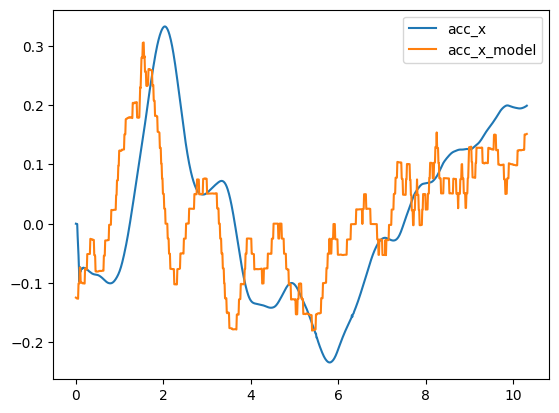

In [25]:
#X_ddot
plt.figure()
plt.plot((ts-ts[0])/1000,acc_x, label = 'acc_x')
plt.plot((ts-ts[0])/1000,acc_x_data, label = 'acc_x_model')
plt.legend()

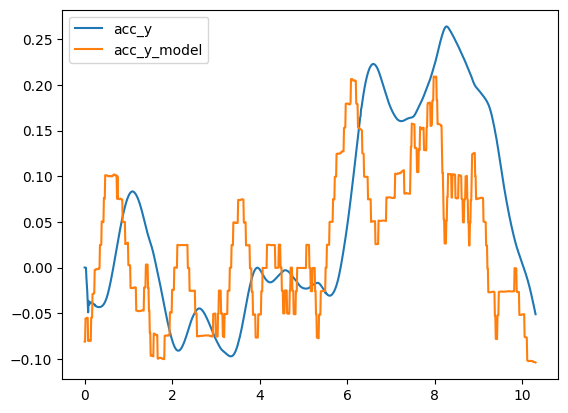

In [26]:
# Y_ddot
plt.figure()
plt.plot((ts-ts[0])/1000,acc_y, label = 'acc_y')
plt.plot((ts-ts[0])/1000,acc_y_data, label = 'acc_y_model')
plt.legend()

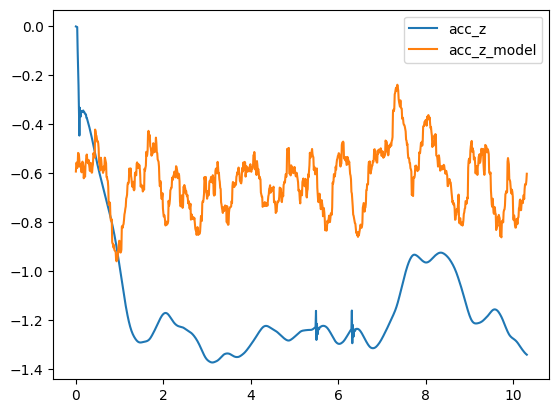

In [27]:
# Z_ddot
plt.figure()
plt.plot((ts-ts[0])/1000,acc_z, label = 'acc_z')
plt.plot((ts-ts[0])/1000,acc_z_data, label = 'acc_z_model')
plt.legend()

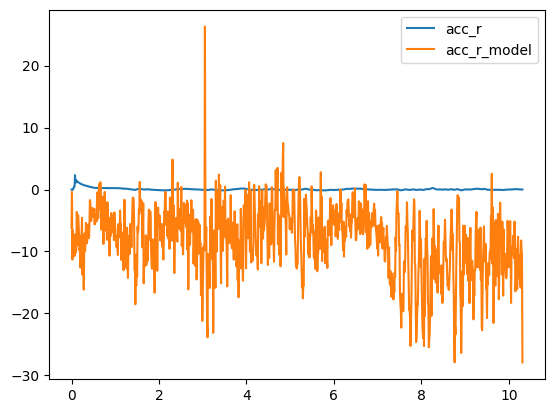

In [28]:
# Roll_ddot
plt.figure()
plt.plot((ts-ts[0])/1000,acc_r, label = 'acc_r')
plt.plot((ts-ts[0])/1000,r_dd_data, label = 'acc_r_model')
plt.legend()

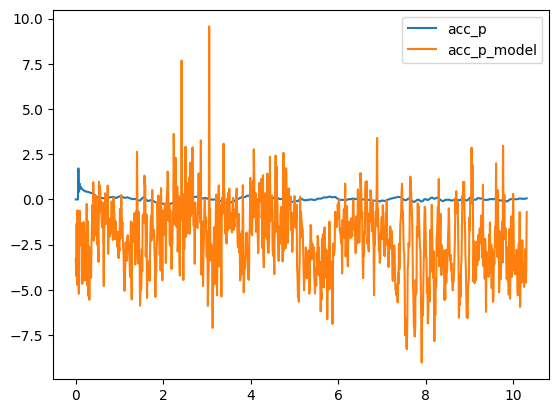

In [29]:
# Pitch_ddot
plt.figure()
plt.plot((ts-ts[0])/1000,acc_p, label = 'acc_p')
plt.plot((ts-ts[0])/1000,p_dd_data, label = 'acc_p_model')
plt.legend()

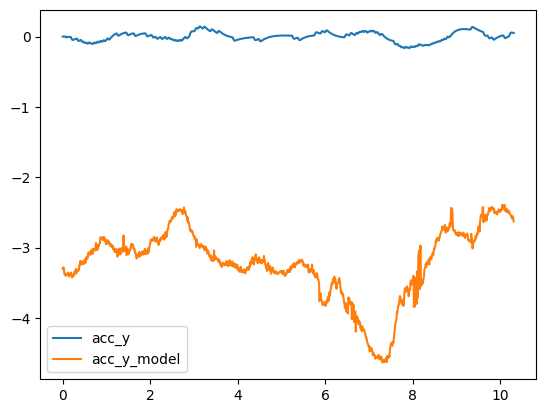

In [30]:
# Yaw_ddot
plt.figure()
plt.plot((ts-ts[0])/1000,acc_ya, label = 'acc_y')
plt.plot((ts-ts[0])/1000,y_dd_data, label = 'acc_y_model')
plt.legend()

In [31]:
acc_x = np.array(acc_x[1:])
acc_y = np.array(acc_y[1:])
acc_z = np.array(acc_z[1:])

In [32]:
acc_x

array([[-1.56201230e-04],
       [-3.47508194e-04],
       [-5.21807074e-04],
       ...,
       [ 1.98104304e-01],
       [ 1.98609564e-01],
       [ 1.99169264e-01]])

In [33]:
mass = []
for i in range(acc_x.shape[0]):
        r = R.from_euler('xyz', np.array([roll[i],pitch[i], yaw[i]]), degrees=False)
        rotation = r.as_matrix()
        thrust = np.array([0,0,thr_tot[i]])
        comp_acc = np.array([acc_x[i], acc_y[i], acc_z[i]]) + np.array([0,0,9.81])
#         print(np.linalg.pinv(comp_acc).shape)
#         print(np.matmul(rotation,thrust).shape)
        mass.append(np.matmul(np.linalg.pinv(comp_acc), np.matmul(rotation,thrust)))

In [34]:
np.mean(np.array(mass))

-0.4419279979921202

In [35]:
import pynumdiff

2023-04-22 23:31:32,662 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2023-04-22 23:31:32,663 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2023-04-22 23:31:32,663 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



In [36]:
roll_d, roll_dd = pynumdiff.finite_difference.first_order(df['stateZ_rollrate']/1000, 1)
pitch_d, pitch_dd = pynumdiff.finite_difference.first_order(df['stateZ_pitchrate']/1000, 1)
yaw_d, yaw_dd = pynumdiff.finite_difference.first_order(df['stateZ_yawrate']/1000, 1)

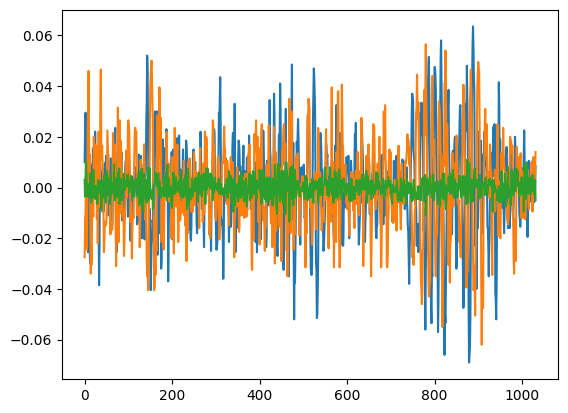

In [37]:
plt.figure()
plt.plot(roll_dd[200:-200])
plt.plot(pitch_dd[200:-200])
plt.plot(yaw_dd[200:-200])

In [38]:
I_x = []
I_y = []
I_z = []

for i in range(roll_d.shape[0]-400):
    torque = np.array([x_torques[i], y_torques[i], z_torques[i]])
    r = roll[i]
    p = pitch[i]
    y = yaw[i]
    r_d = roll_d[i]
    p_d = pitch_d[i]
    y_d = yaw_d[i]
    r_dd = roll_dd[i]
    p_dd = pitch_dd[i]
    y_dd = yaw_dd[i]
    W_n = []
    # ν = Wη η
    # ν_d = Wη_d η + Wη η_d
    # Iν_d + ν*Iν = τ 
    # I(Wη_d η + Wη η_d) + (Wη η)*I(Wη η) = τ 
    P = r_d - np.sin(p)*y_d
    Q = np.cos(r)*p_d + np.cos(p)*np.sin(r)*y_d
    R = -np.sin(r)*p_d + np.cos(p)*np.cos(r)*y_d
    P_d = r_dd - np.sin(p)*y_dd  - np.cos(p)*y_d*p_d
    Q_d = np.cos(r)*p_dd -np.sin(r)*r_d*p_d + np.cos(p)*np.sin(r)*y_dd - np.sin(p)*p_d*np.sin(r)*y_d + np.cos(p)*np.cos(r)*r_d*y_d
    R_d = -np.sin(r)*p_dd -np.cos(r)*r_d*p_d + np.cos(p)*np.cos(r)*y_dd - np.sin(p)*p_d*np.cos(r)*y_d -np.cos(p)*np.sin(r)*r_d*y_d
    w_d_w = np.diag([P_d, Q_d, R_d]) + np.array([[0,-Q*R, Q*R ],[P*R, 0, -P*R ],[-P*Q, P*Q, 0]])
#     print(w_d_w, torque)
    J = np.matmul(np.linalg.pinv(w_d_w), torque)
#     print(J[0])
    I_x.append(J[0])
    I_y.append(J[1])
    I_z.append(J[2])
#     r = R.from_euler('xyz', np.array([roll[i],pitch[i], yaw[i]]), degrees=False)
#     rotation = r.as_matrix()
#     thrust = np.array([0,0,thr_tot[i]])
#     comp_acc = np.array([acc_x[i], acc_y[i], acc_z[i]]) + np.array([0,0,9.81])
#     # print(np.linalg.pinv(comp_acc.reshape(-1,1)).shape)
#     # print(np.matmul(rotation,thrust).shape)
#     mass.append(np.matmul(np.linalg.pinv(comp_acc.reshape(-1,1)), np.matmul(rotation,thrust)))

In [39]:
I_x[-1]=0
np.mean(np.array(I_x))

-0.0028075947533987497

In [40]:
I_y[-1]=0
np.mean(np.array(I_y))

-0.5213864178101263

In [41]:
I_z[-1]=0
np.mean(np.array(I_z))

0.11041248344677518